## Plot degree versus clustering coefficient/eigenvector centrality/knn

In [1]:
library(tidyverse)
centrality_measures <- read_csv(
    "scibert_network/results/title_embeddings/centrality_measures.csv"
)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
New names:
• `` -> `...1`
Rows: 25877 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


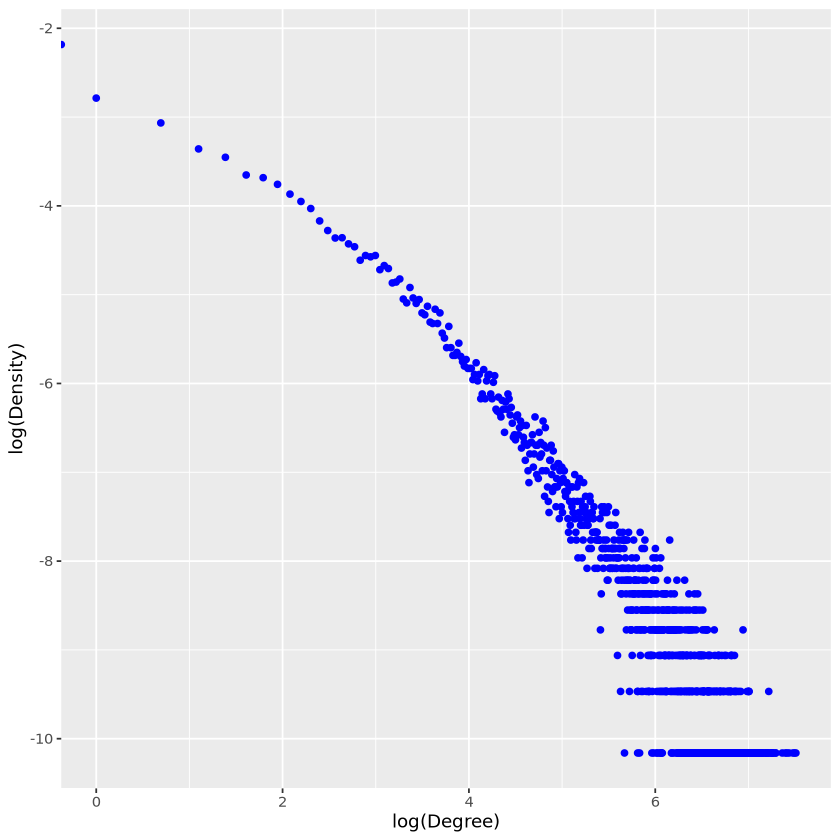

In [2]:
#degree distribution
degrees <- centrality_measures %>%
    group_by(Degree) %>%
    summarize(Density = n()/nrow(centrality_measures))
ggplot(data = degrees, aes(x = log(Degree), y = log(Density))) +
    geom_point(color = "blue")

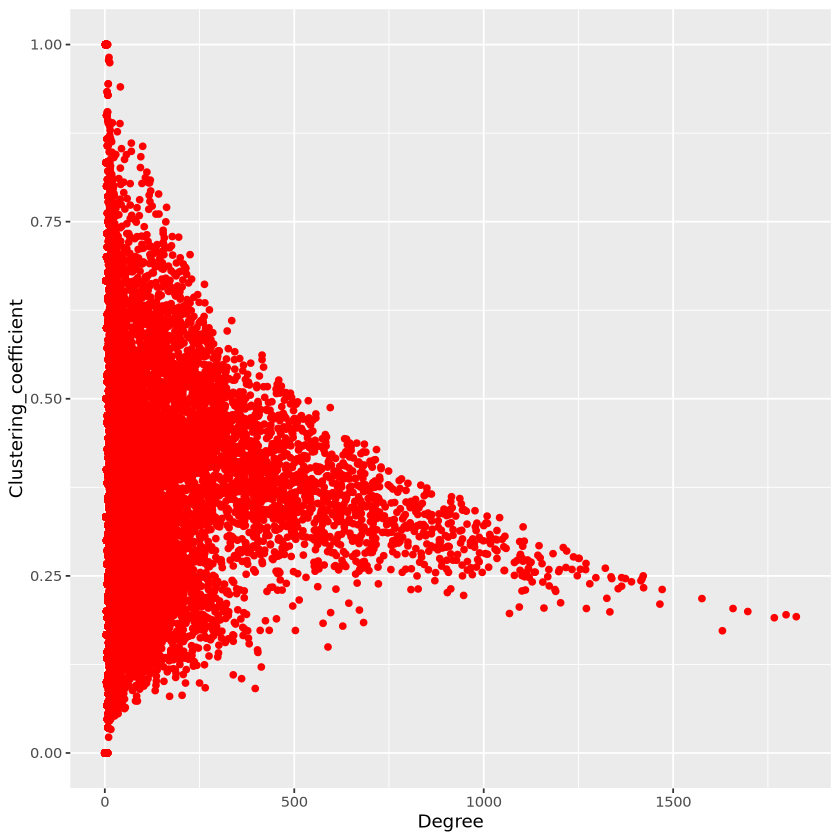

In [3]:
#clustering coefficient vs degree
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient)) +
    geom_point(color = "red")

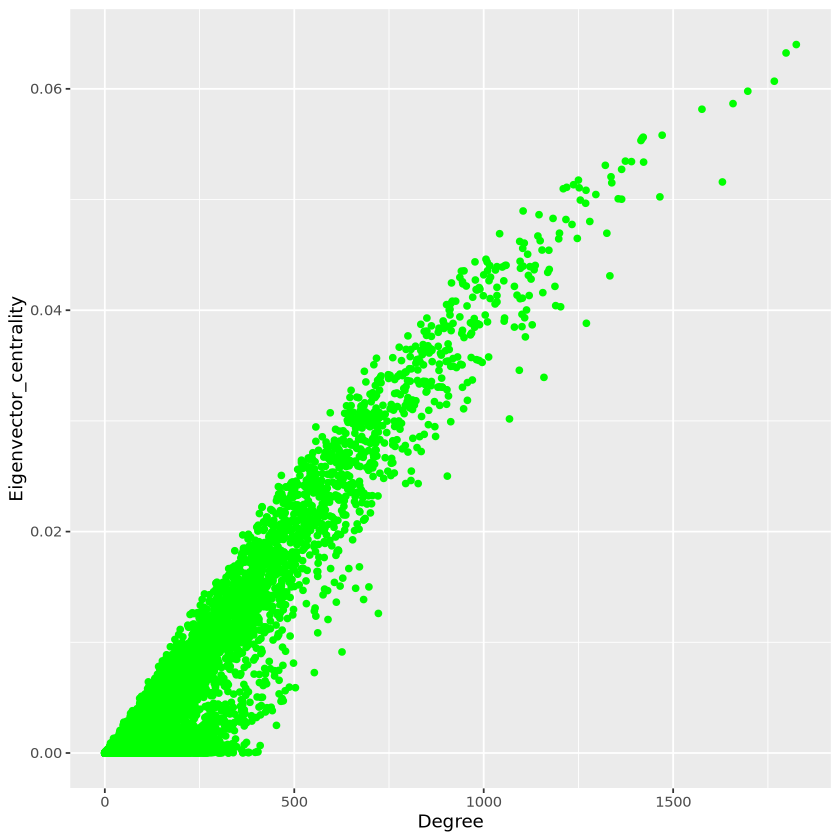

In [4]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality)) +
    geom_point(color = "green")

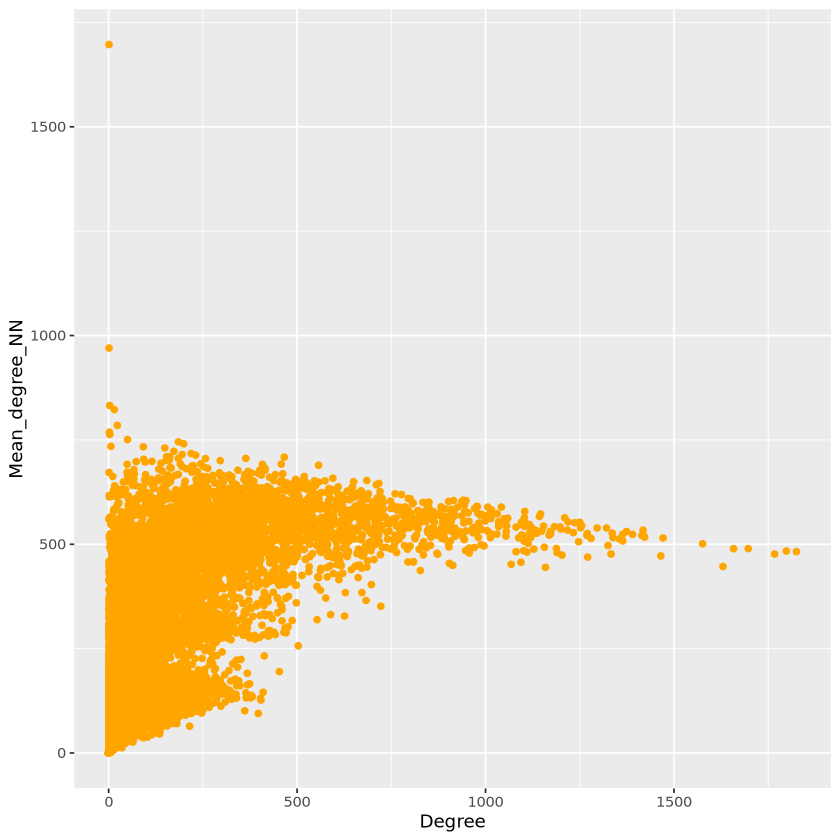

In [5]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN)) +
    geom_point(color = "orange")

## Analyze network degrees

In [6]:
#create a unique dataset with the papers and their degree (and topic)
all_papers <- read_csv(
    "data/all_papers.csv"
)
all_data <- bind_cols(all_papers, centrality_measures)

New names:
• `` -> `...1`
Rows: 25877 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): authors, title, abstract, primary_cathegory, secondary_cathegory
dbl (2): ...1, paper

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `...1` -> `...8`


In [7]:
all_data %>%
    select(c("paper", "title", "primary_cathegory", "secondary_cathegory", "Degree")) %>%
    mutate("Index" = c(0:(nrow(all_data) - 1))) %>%
    arrange(desc(Degree))

paper,title,primary_cathegory,secondary_cathegory,Degree,Index
<dbl>,<chr>,<chr>,<chr>,<dbl>,<int>
2512.014,Extension of interferometric particle imaging to small ice-crystal sizes using the Discrete Dipole Approximation,Optics,Instrumentation and Detectors,1825,15742
2505.030,An Exact Turbulence Law For the Fluid Description of Fusion Edge Plasmas,Plasma Physics,Plasma Physics,1798,5626
2501.037,The role of Berry curvature derivatives in the optical activity of time-invariant crystals,Mesoscale and Nanoscale Physics,Optics,1767,17589
2503.127,Unveiling a New $\beta$-Scaling of the Tearing Instability in Weakly Collisional Plasmas,Plasma Physics,Plasma Physics,1697,3296
2501.121,Unveiling the thermal transport mechanism in compressed plastic crystals assisted by deep potential,Materials Science,Applied Physics,1658,17902
2512.233,Spectral Analysis of Hard-Constraint PINNs: The Spatial Modulation Mechanism of Boundary Functions,Machine Learning,Computational Physics,1630,25831
2501.165,Decrypting the temperature field in flow boiling with latent diffusion models,Fluid Dynamics,Fluid Dynamics,1576,1176
2506.154,An investigation into the nonconformity of homogeneous gas limit for kinetic energy density of atomic systems,Chemical Physics,Chemical Physics,1471,7673
2501.013,"The reformed hydrodynamic Schr\""odinger equation and the effective method for eliminating pseudo-quantum potential: a case study on barotropic potential flow",Fluid Dynamics,Fluid Dynamics,1465,95


In [8]:
mean(all_data$Degree)

[1] 73.34846

In [9]:
median(all_data$Degree)

[1] 17

In [10]:
mean(all_data$Mean_degree_NN)

[1] 137.8613

## Comparison with random network

In [ ]:
library(tidyverse)
centrality_measures <- read_csv(
    "scibert_network/results/random_network/centrality_measures.csv"
)

New names:
• `` -> `...1`


Rows: 25877 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


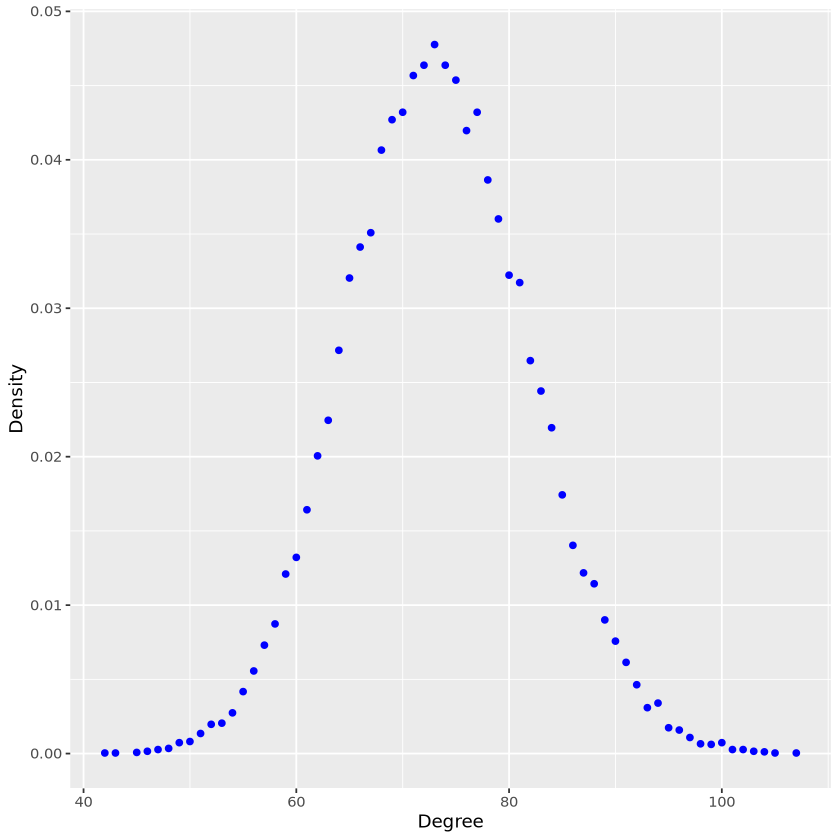

In [ ]:
#degree distribution
degrees <- centrality_measures %>%
    group_by(Degree) %>%
    summarize(Density = n()/nrow(centrality_measures))
ggplot(data = degrees, aes(x = Degree, y = Density)) +
    geom_point(color = "blue")

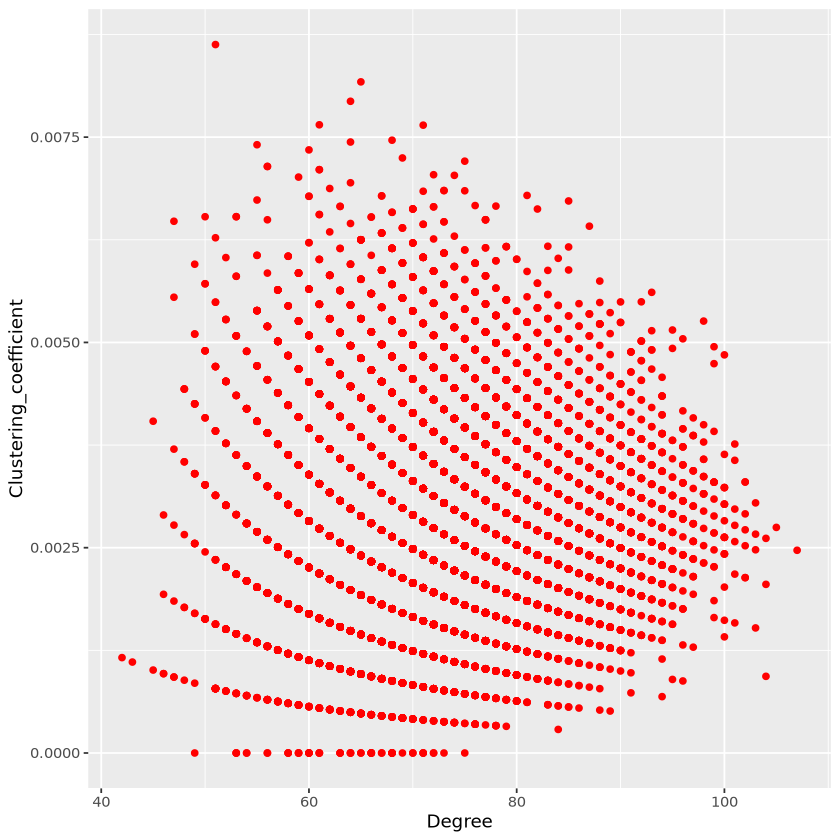

In [ ]:
#clustering coefficient vs degree
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient)) +
    geom_point(color = "red")

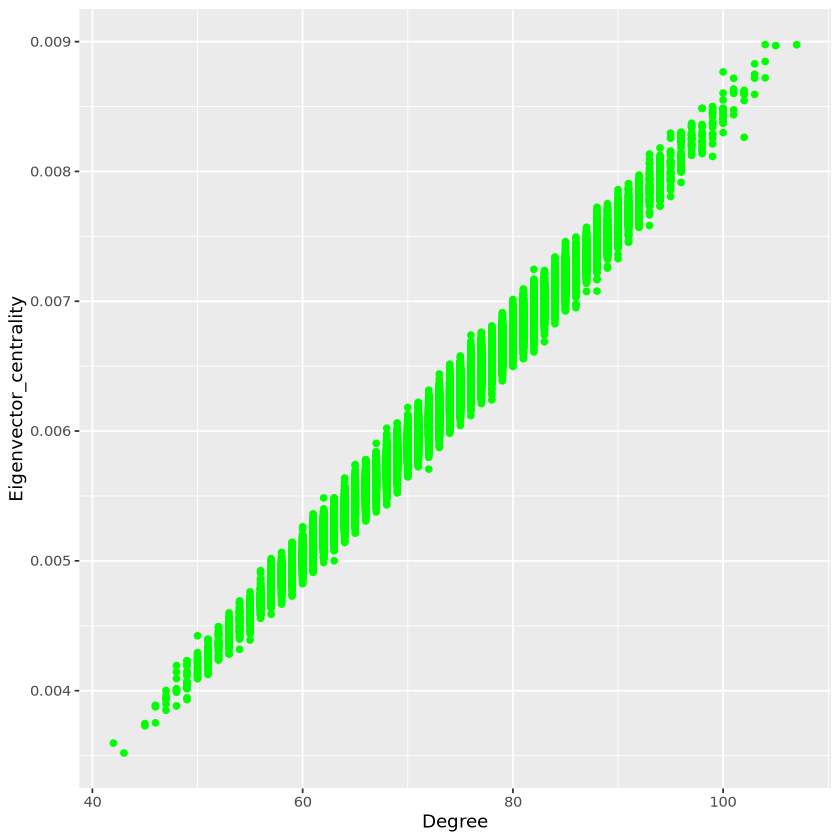

In [ ]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality)) +
    geom_point(color = "green")

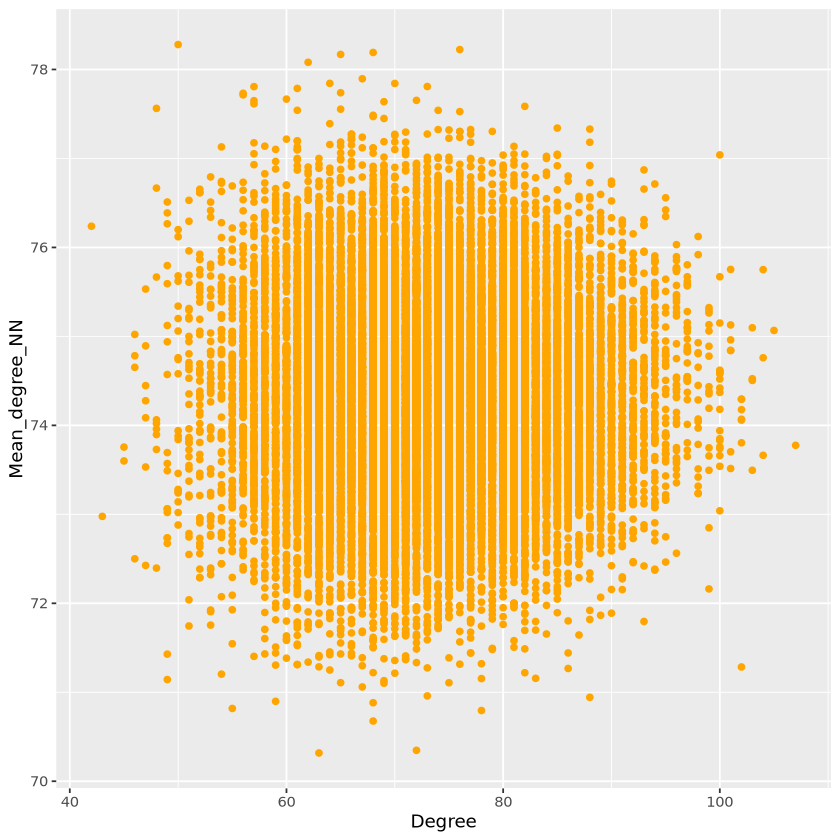

In [ ]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN)) +
    geom_point(color = "orange")

## Comparison with scale-free network

In [ ]:
library(tidyverse)
centrality_measures <- read_csv(
    "scibert_network/results/scale_free_network/centrality_measures.csv"
)

New names:
• `` -> `...1`
Rows: 25877 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


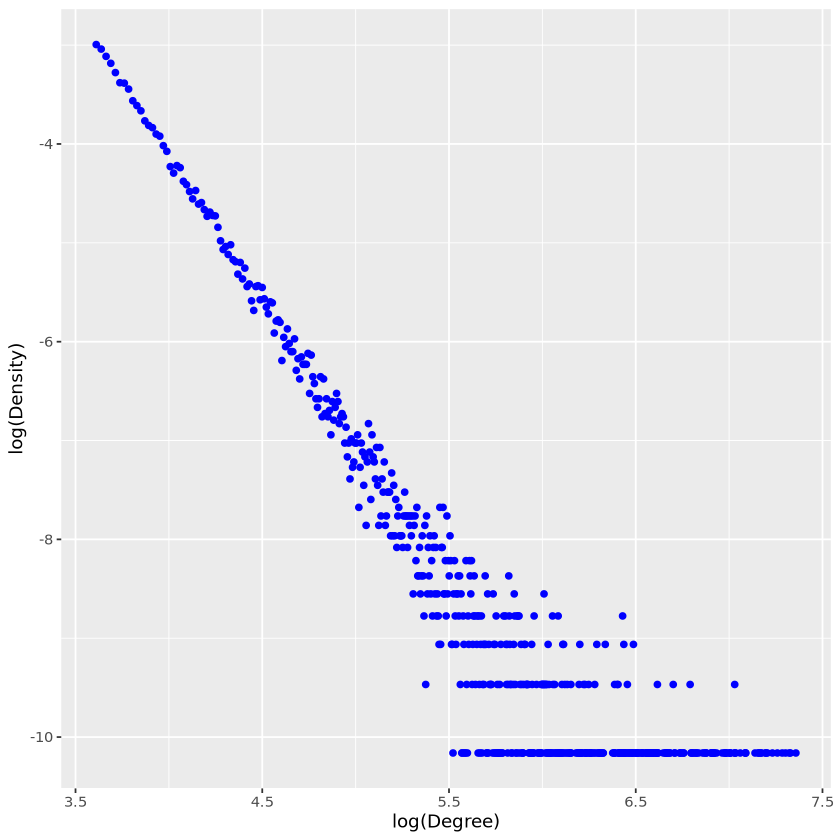

In [ ]:
#degree distribution
degrees <- centrality_measures %>%
    group_by(Degree) %>%
    summarize(Density = n()/nrow(centrality_measures))
ggplot(data = degrees, aes(x = log(Degree), y = log(Density))) +
    geom_point(color = "blue")

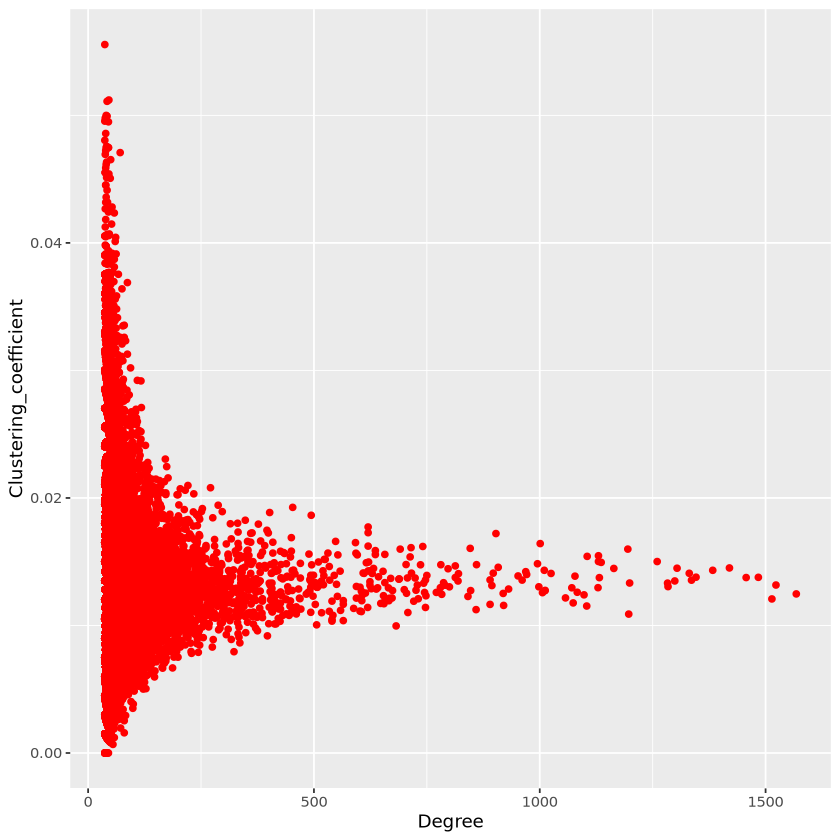

In [ ]:
#clustering coefficient vs degree
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient)) +
    geom_point(color = "red")

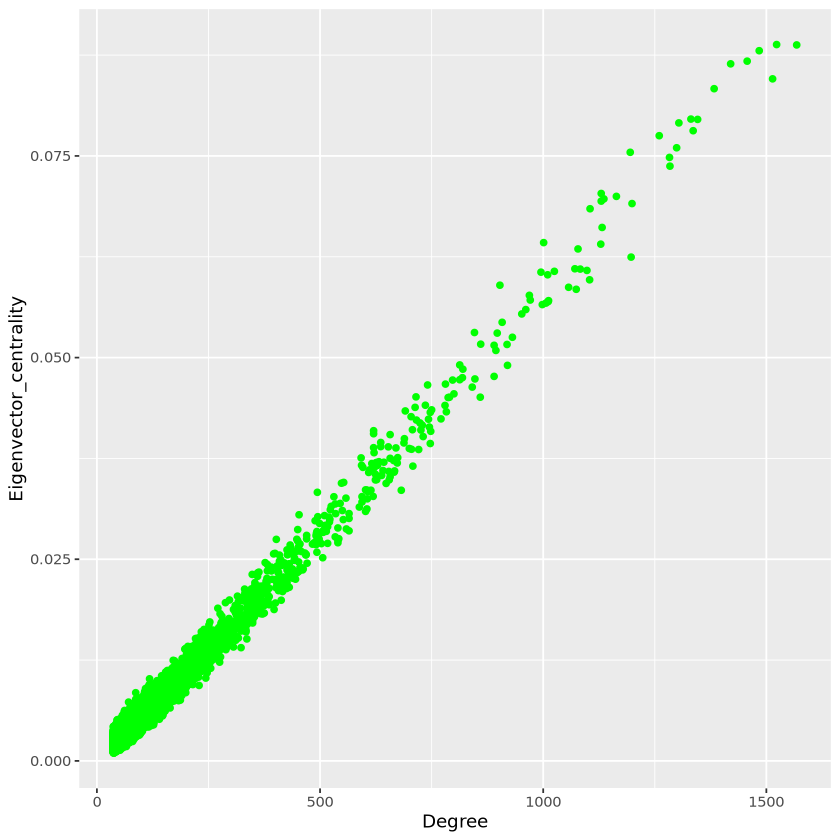

In [ ]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality)) +
    geom_point(color = "green")

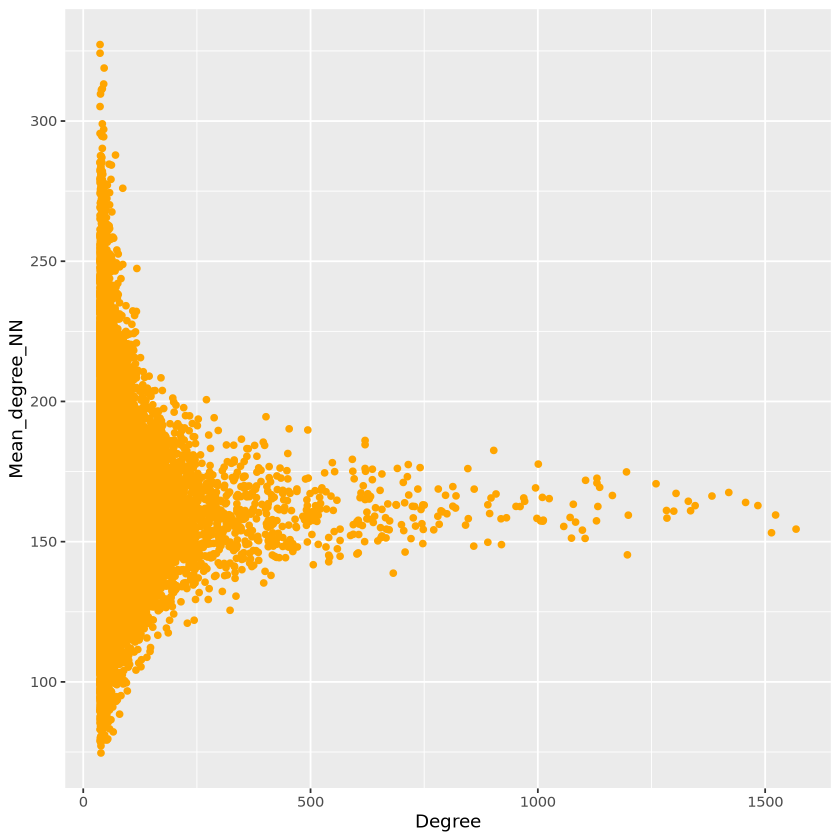

In [ ]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN)) +
    geom_point(color = "orange")

## Comparison with graph after node removal

In [ ]:
library(tidyverse)
centrality_measures <- read_csv(
    "scibert_network/results/title_node_removal/centrality_measures.csv"
)

New names:
• `` -> `...1`
Rows: 25867 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


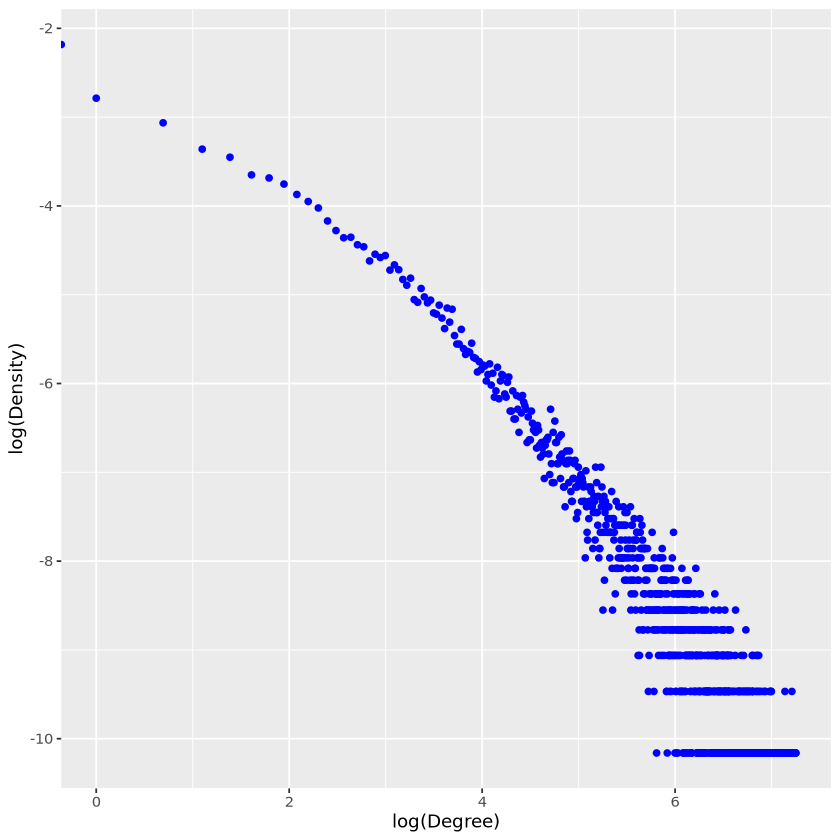

In [ ]:
#degree distribution
degrees <- centrality_measures %>%
    group_by(Degree) %>%
    summarize(Density = n()/nrow(centrality_measures))
ggplot(data = degrees, aes(x = log(Degree), y = log(Density))) +
    geom_point(color = "blue")

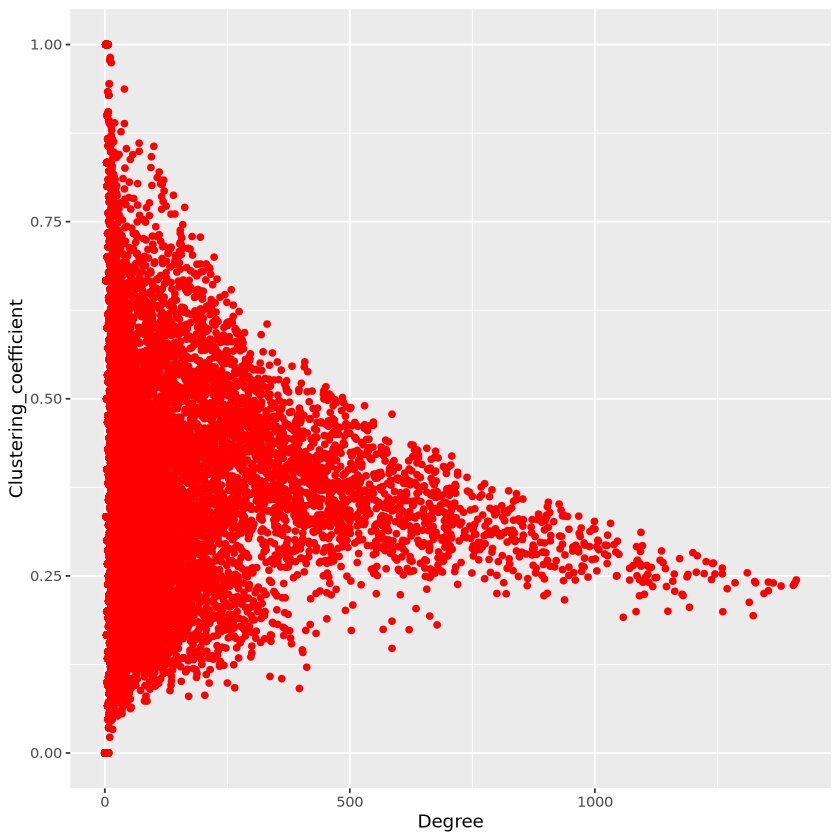

In [ ]:
#clustering coefficient vs degree
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient)) +
    geom_point(color = "red")

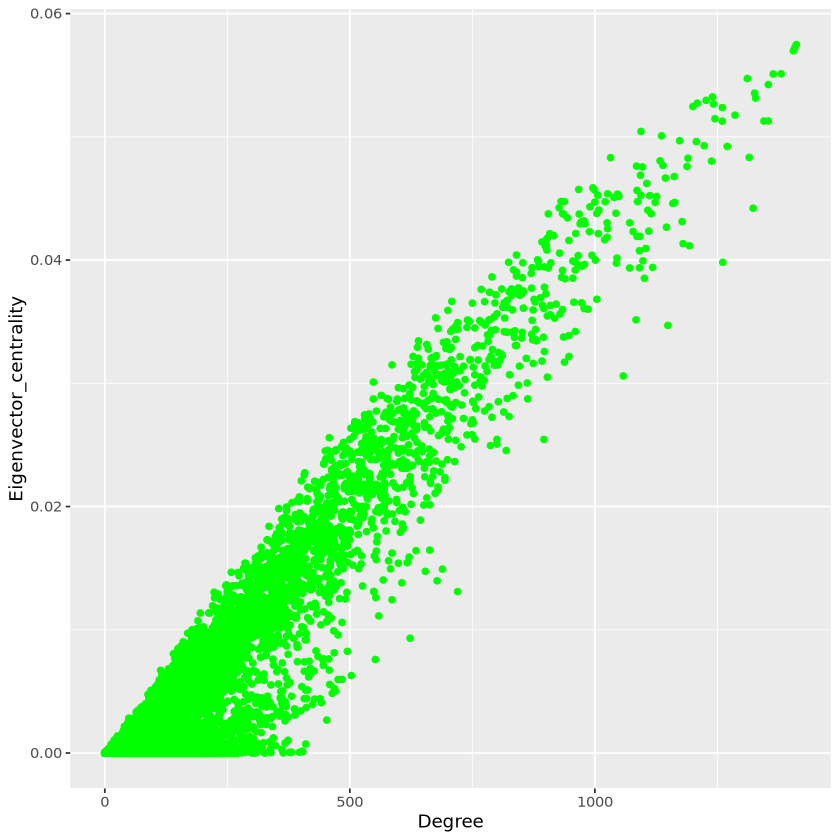

In [ ]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality)) +
    geom_point(color = "green")

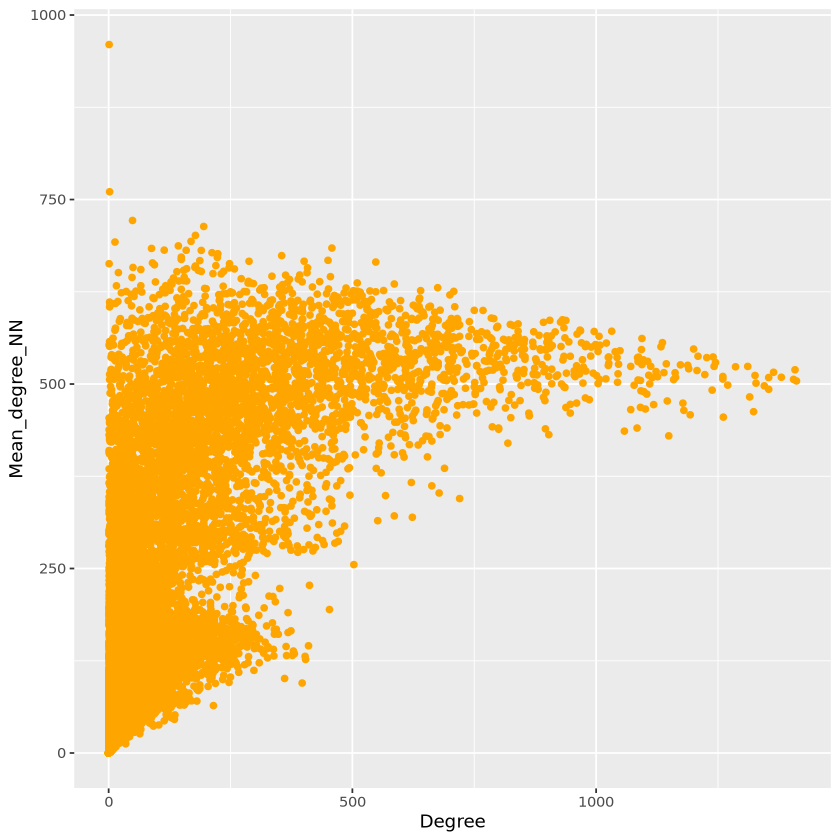

In [ ]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN)) +
    geom_point(color = "orange")

## Comparison with link reshuffling

In [2]:
library(tidyverse)
centrality_measures <- read_csv(
    "scibert_network/results/link_shuffle/centrality_measures.csv"
)

New names:
• `` -> `...1`
Rows: 25877 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (5): ...1, Degree, Clustering_coefficient, Eigenvector_centrality, Mean_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


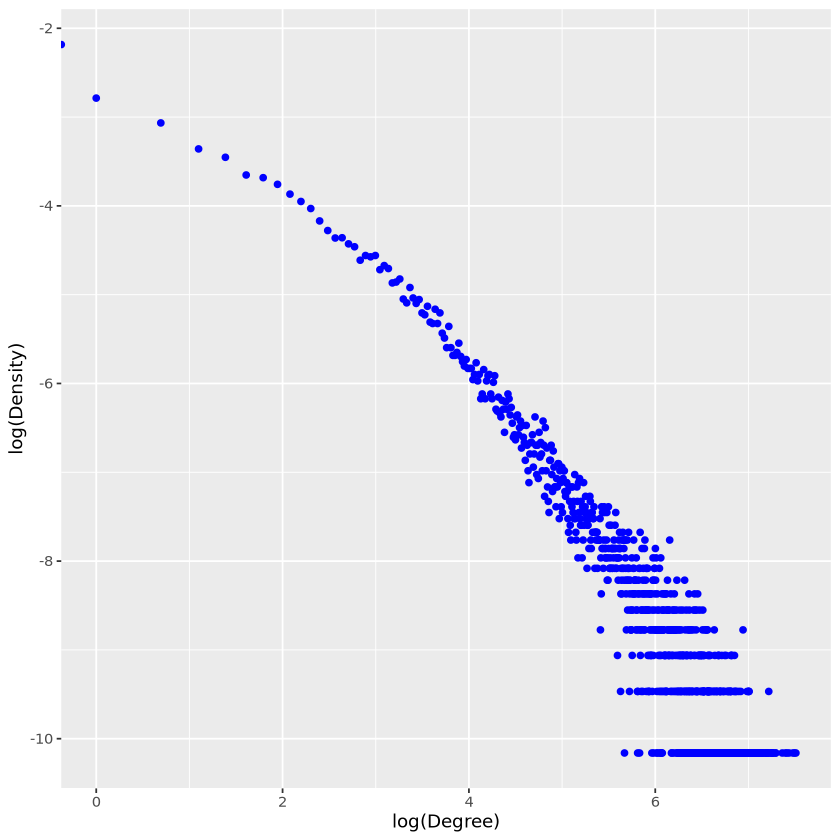

In [3]:
#degree distribution
degrees <- centrality_measures %>%
    group_by(Degree) %>%
    summarize(Density = n()/nrow(centrality_measures))
ggplot(data = degrees, aes(x = log(Degree), y = log(Density))) +
    geom_point(color = "blue")

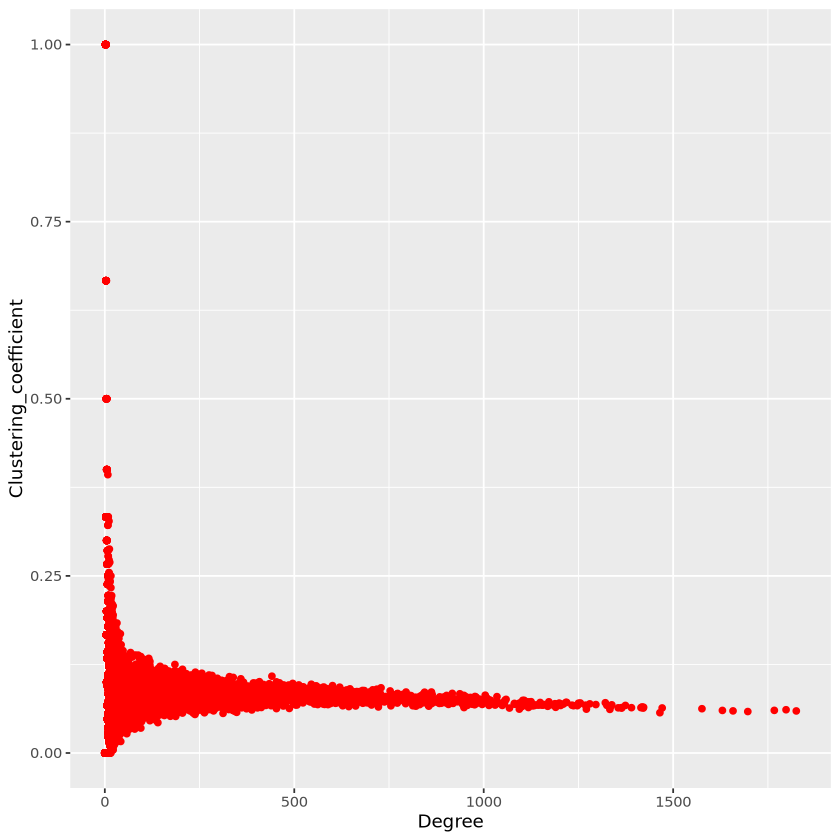

In [4]:
#clustering coefficient vs degree
ggplot(data = centrality_measures, aes(x = Degree, y = Clustering_coefficient)) +
    geom_point(color = "red")

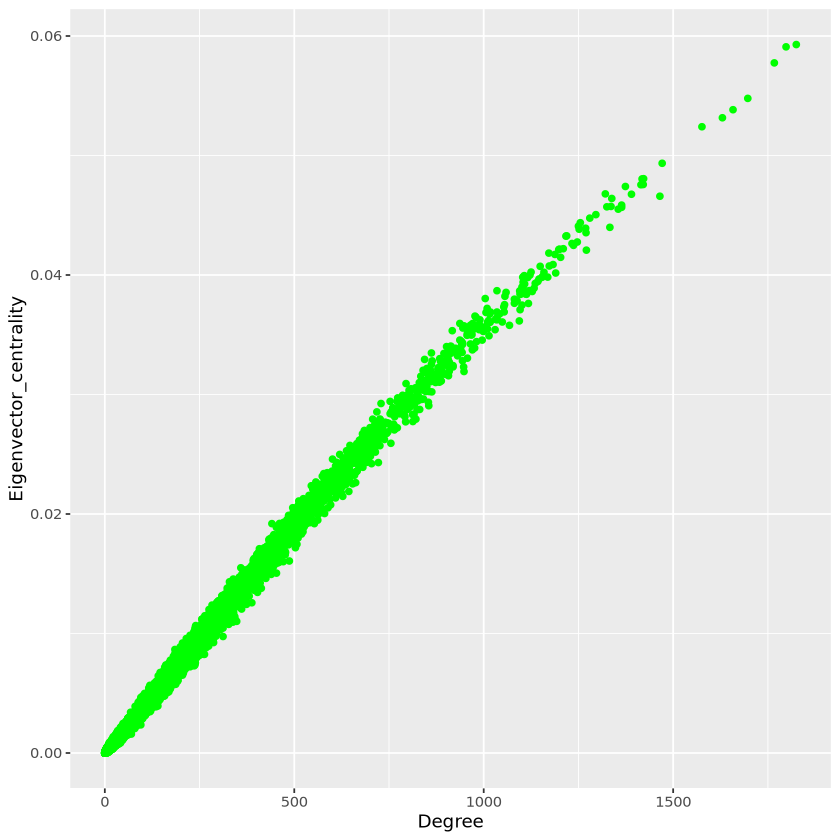

In [5]:
ggplot(data = centrality_measures, aes(x = Degree, y = Eigenvector_centrality)) +
    geom_point(color = "green")

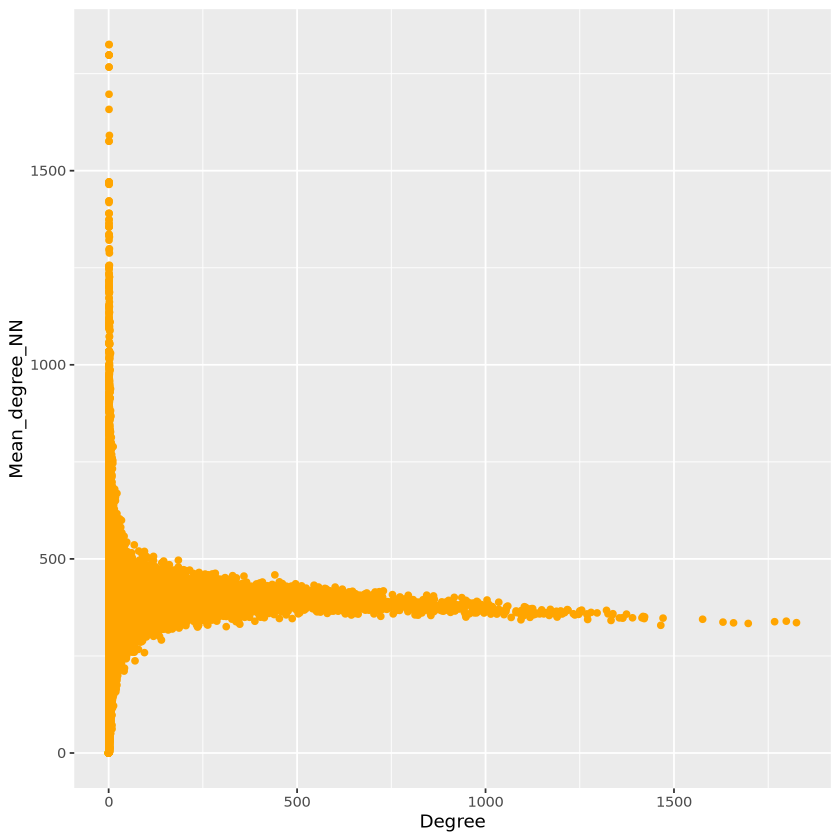

In [6]:
#knn
ggplot(data = centrality_measures, aes(x = Degree, y = Mean_degree_NN)) +
    geom_point(color = "orange")